# Mexico Earthquake Interactive Map

## Data Exploration and Cleaning

### 1. Initial Load and Structure Check

When importing the CSV generated by the 'load_data.py' file, the first step is to verify that Python correctly recognizes dates and coordinates.

In [11]:
import pandas as pd

# load the dataset
df = pd.read_csv('../data/earthquakes.csv')

# Check columns and data typesm
print(df.info())
print(df.head())


<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       81 non-null     str    
 1   latitude   81 non-null     float64
 2   longitude  81 non-null     float64
 3   depth      81 non-null     float64
 4   magnitude  81 non-null     float64
 5   place      81 non-null     str    
dtypes: float64(4), str(2)
memory usage: 3.9 KB
None
                      date   latitude  longitude   depth  magnitude  \
0  2026-03-16 10:11:16.351  32.780000   -100.559  4.0283       2.60   
1  2026-03-16 07:45:43.280  31.515667   -115.647  0.9000       3.29   
2  2026-03-16 06:46:19.661  31.660000   -104.403  5.8948       3.00   
3  2026-03-15 20:20:12.339  31.692000   -104.401  4.8181       3.50   
4  2026-03-15 06:44:59.623  31.669000   -104.202  7.5739       2.50   

                                place  
0            11 km SW of Rotan, Texas  
1    90 km ESE of Maneadero, 

### Data Cleaning

Although the API is reliable, occasionally there may be records with negative magnitudes (sensor errors) or missing depth data.

* **Date Conversion:** Ensure the `date` column is a `datetime` object to enable filtering by days or months later.
* **Null Removal:** In seismology, events without coordinates or magnitude are useless for our map.

In [12]:
# Convert date to datetime if not done in previous step
df['date'] = pd.to_datetime(df['date'])

# Remove null values in critical columns
df = df.dropna(subset=['latitude', 'longitude', 'magnitude'])

###  Magnitude and Depth Range Review

Understanding the minimum and maximum values is essential for configuring the **color scale** of our interactive map. You wouldn't want a magnitude 3.0 earthquake to have the same visual size as a 7.5 one.

In [13]:
# Statistical summary
stats = df[['magnitude', 'depth']].describe()
print(stats)

# Logical range validation
# Earthquakes in Mexico typically range from 0 to 200+ km in depth
print(f"Magnitude Range: {df.magnitude.min()} - {df.magnitude.max()}")

       magnitude       depth
count  81.000000   81.000000
mean    3.170864   13.508385
std     0.724184   28.821261
min     2.500000    0.900000
25%     2.600000    5.946000
50%     2.900000    6.202400
75%     3.500000    9.421000
max     4.900000  184.119000
Magnitude Range: 2.5 - 4.9



## Quick Visual Analysis (EDA)

Before diving into `geopandas`, you can use a simple scatter plot to see if the points outline "the shape of Mexico." This will confirm that latitudes and longitudes aren't inverted.

### What to Look for in This Step

* **Outliers:** Are there any earthquakes with latitude 0 or longitude 0? (This would indicate an API error).
* **Density:** Are most earthquakes along the Pacific coast (Guerrero, Oaxaca, Chiapas)? If so, your data is consistent with Mexico's tectonic reality.


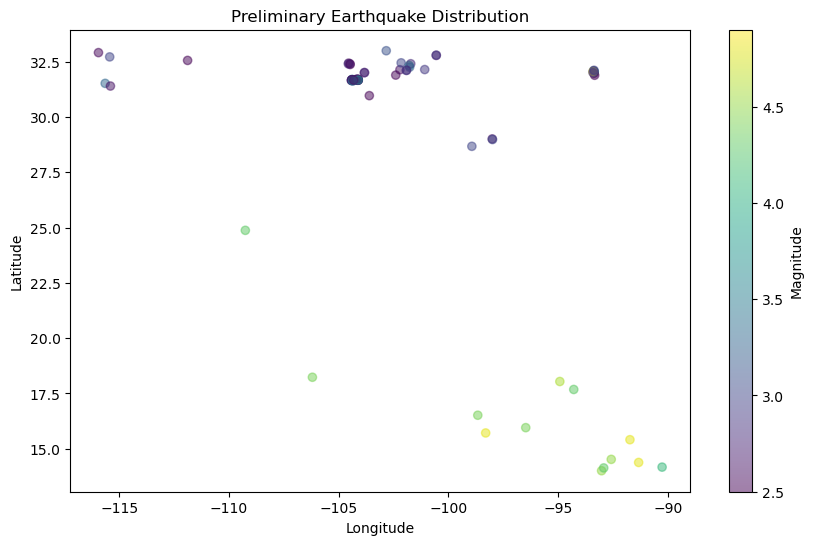

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['magnitude'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Magnitude')
plt.title('Preliminary Earthquake Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Paso 6: Visualización Exploratoria Estática 🗺️

Antes de generar el mapa interactivo final en HTML, es fundamental realizar una **validación geoespacial estática**. Esto nos permite asegurar que la relación entre nuestras dos fuentes de datos es correcta.

### Objetivos de esta etapa:
1. **Validación de Capas:** Confirmar que el GeoJSON de los estados de México y los puntos de sismos se superponen correctamente.
2. **Integridad del CRS:** Verificar que ambos datasets comparten el mismo Sistema de Referencia de Coordenadas (**EPSG:4326**).
3. **Análisis de Distribución:** Observar preliminarmente las zonas de mayor actividad sísmica (Cinturón de Fuego del Pacífico y Placa del Coco).

### Lógica de Visualización:
* **Fondo:** Mapa base de los estados de México (Polígonos).
* **Tamaño del punto (`markersize`):** Proporcional a la **Magnitud** (exponencial para resaltar sismos fuertes).
* **Color (`cmap`):** Gradiente basado en la **Magnitud** para identificar visualmente los eventos más críticos.

---

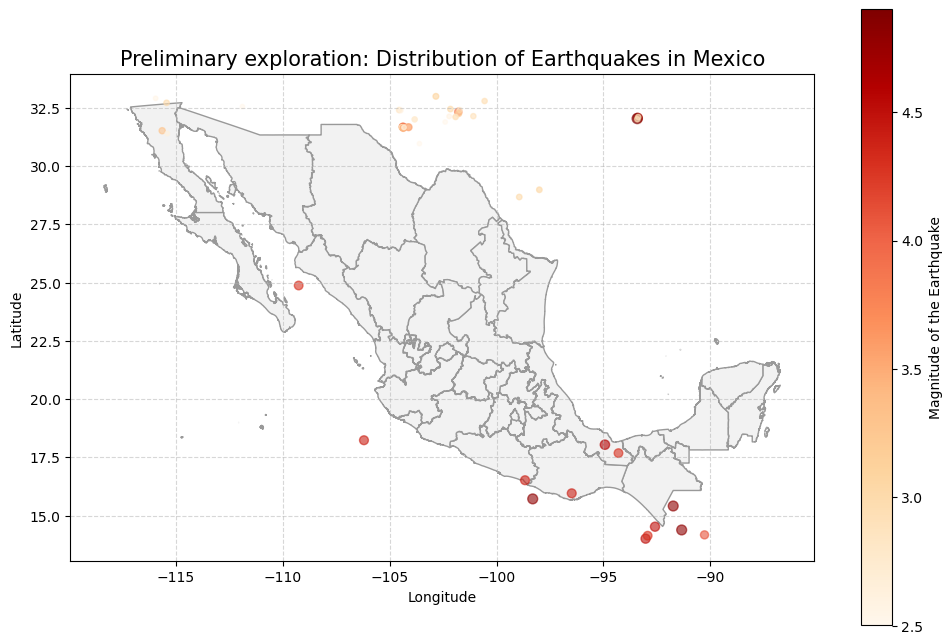

In [17]:
import geopandas as gpd

# load GeoJSON of the states (Context)
# Make sure the path is correct according to your structure
mexico_states = gpd.read_file('../data/mexico_states.geojson')

# 2. Load the CSV and convert it to a GeoDataFrame (Earthquakes dataset)
df_sismos = pd.read_csv('../data/earthquakes.csv')
gdf_sismos = gpd.GeoDataFrame(
    df_sismos, 
    geometry=gpd.points_from_xy(df_sismos.longitude, df_sismos.latitude),
    crs="EPSG:4326"
)

# 3. CRS validation and transformation if needed
if mexico_states.crs != gdf_sismos.crs:
    mexico_states = mexico_states.to_crs(gdf_sismos.crs)

# 4. static exploratoryVisualization 
fig, ax = plt.subplots(figsize=(12, 8))

# draw the base map of mexico states
mexico_states.plot(ax=ax, color='#f2f2f2', edgecolor='#999999', label='Estados')

# draw the earthquis encima
# size depends on the magnitud 
gdf_sismos.plot(
    ax=ax, 
    column='magnitude', 
    cmap='OrRd', 
    markersize=gdf_sismos['magnitude']**2.5, 
    alpha=0.6, 
    legend=True,
    legend_kwds={'label': "Magnitude of the Earthquake"}
)

# personalase graph
plt.title('Preliminary exploration: Distribution of Earthquakes in Mexico', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('../output/preliminary_exploration.png', dpi=300, bbox_inches='tight')
plt.show()